In [2]:
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np

In [3]:
dataset = pd.read_csv('../Dataset/online_retail.csv')

In [4]:
dataset.head()

,InvoiceNo,StockCode,Description,Quantity,InvoiceDate,UnitPrice,CustomerID,Country
0,536365,85123A,WHITE HANGING HEART T-LIGHT HOLDER,6,2010-12-01 08:26:00,2.55,17850.0,United Kingdom
1,536365,71053,WHITE METAL LANTERN,6,2010-12-01 08:26:00,3.39,17850.0,United Kingdom
2,536365,84406B,CREAM CUPID HEARTS COAT HANGER,8,2010-12-01 08:26:00,2.75,17850.0,United Kingdom
3,536365,84029G,KNITTED UNION FLAG HOT WATER BOTTLE,6,2010-12-01 08:26:00,3.39,17850.0,United Kingdom
4,536365,84029E,RED WOOLLY HOTTIE WHITE HEART.,6,2010-12-01 08:26:00,3.39,17850.0,United Kingdom


In [5]:
dataset.info()

<class 'pandas.DataFrame'>
RangeIndex: 541909 entries, 0 to 541908
Data columns (total 8 columns):
 #   Column       Non-Null Count   Dtype  
---  ------       --------------   -----  
 0   InvoiceNo    541909 non-null  str    
 1   StockCode    541909 non-null  str    
 2   Description  540455 non-null  str    
 3   Quantity     541909 non-null  int64  
 4   InvoiceDate  541909 non-null  str    
 5   UnitPrice    541909 non-null  float64
 6   CustomerID   406829 non-null  float64
 7   Country      541909 non-null  str    
dtypes: float64(2), int64(1), str(5)
memory usage: 69.3 MB


In [6]:
dataset.describe()

,Quantity,UnitPrice,CustomerID
count,541909.000000,541909.000000,406829.000000
mean,9.552250,4.611114,15287.690570
std,218.081158,96.759853,1713.600303
min,-80995.000000,-11062.060000,12346.000000
25%,1.000000,1.250000,13953.000000
50%,3.000000,2.080000,15152.000000
75%,10.000000,4.130000,16791.000000
max,80995.000000,38970.000000,18287.000000


In [7]:
dataset.isnull().sum()

InvoiceNo           0
StockCode           0
Description      1454
Quantity            0
InvoiceDate         0
UnitPrice           0
CustomerID     135080
Country             0
dtype: int64

### Data Cleaning

In [8]:
dataset = dataset.dropna(subset=['CustomerID']) # Remove data yg gaada CustID

In [9]:
dataset = dataset[dataset['Quantity'] > 0] # Remove Failed Transaction (cancel)

In [10]:
dataset['InvoiceDate'] = pd.to_datetime(dataset['InvoiceDate'])

dataset['TotalPrice'] = dataset['Quantity'] * dataset['UnitPrice']

### Kalkulasi RFM

In [11]:
reference_date = dataset['InvoiceDate'].max() + pd.Timedelta(days=1) # tanggal acuan (tanggal transaksi akhir di dataset + 1 biar ga 0)

rfm = dataset.groupby('CustomerID').agg({ # group berdasarkan CustomerID
    'InvoiceDate' : lambda x: (reference_date - x.max()).days, # recency (x.max() tanggal terakhir, reference_date - x.max() hitung selisih hari dan diubah ke angka hari (.days)) per customer 
    'InvoiceNo': 'nunique', # frequency (nunique is jumlah invoice unik -> berapa kali customer transaksi (unik->beda transaksi))
    'TotalPrice': 'sum' # monetary (total uang yg dihabiskan customer dijumlah)
})

# Label -> bagi kuartil sama besar, 326 -> label 1 karena masih 20% terbesar paling lama ga beli

rfm.columns = ['Recency', 'Frequency', 'Monetary'] # rename column biar jelas
rfm.head()

,Recency,Frequency,Monetary
CustomerID,,,
12346.0,326,1,77183.60
12347.0,2,7,4310.00
12348.0,75,4,1797.24
12349.0,19,1,1757.55
12350.0,310,1,334.40


### Scoring RFM

In [12]:
rfm['R_score'] = pd.qcut(rfm['Recency'], 5, labels=[5,4,3,2,1]) # bagi data jadi 5 kuartil, skor terbalik karena recency kecil = bagus, sedangkan default qcut kecil = kuartil pertama
rfm['F_score'] = pd.qcut(rfm['Frequency'].rank(method='first'), 5, labels=[1,2,3,4,5]) # pake .rank biar freq bisa banyak nilai sama (kalo gaada, qcut error krn dupe), methode='first' untuk kasih rank unik ke tiap data
rfm['M_score'] = pd.qcut(rfm['Monetary'], 5, labels=[1,2,3,4,5]) # frequency & monetary makin besar makin bagus makanya label 1,2,3,4,5

rfm['RFM_Score'] = rfm[['R_score', 'F_score', 'M_score']].astype(int).sum(axis=1) # jumlahkan R+F+M
rfm.head()

,Recency,Frequency,Monetary,R_score,F_score,M_score,RFM_Score
CustomerID,,,,,,,
12346.0,326,1,77183.60,1,1,5,7
12347.0,2,7,4310.00,5,5,5,15
12348.0,75,4,1797.24,2,4,4,10
12349.0,19,1,1757.55,4,1,4,9
12350.0,310,1,334.40,1,1,2,4


In [13]:
from sklearn.preprocessing import StandardScaler

rfm_ml = rfm[['Recency', 'Frequency', 'Monetary']]

scaler = StandardScaler()
rfm_scaled = scaler.fit_transform(rfm_ml)

### Elbow Method 
-> Untuk cari jumlah cluster terbalik K karena kita gatau jumlah segment dalamm RFM, makanya pake Elbow Method untuk bantu nentuin customer sebaiknya dibagi brp grup

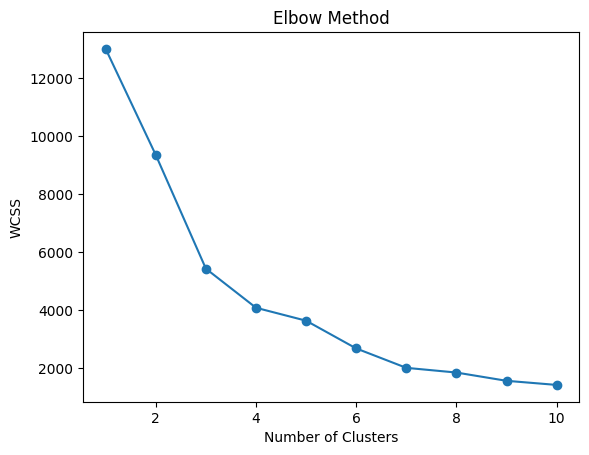

In [14]:
from sklearn.cluster import KMeans
wcss = []

for i in range(1,11): # Cluster 1-10
    kmeans = KMeans(n_clusters=i, random_state=42)
    kmeans.fit(rfm_scaled)
    wcss.append(kmeans.inertia_) # total jarak data ke centroid dalam cluster (makin kecil, cluster makin rapat)

plt.plot(range(1,11), wcss, marker='o')
plt.title('Elbow Method')
plt.xlabel('Number of Clusters')
plt.ylabel('WCSS')
plt.show()

# Hasil grafik elbow menunjukkan titik yang mulai ga turun tajam di titik ke 3-4 tp kita pilih 4

In [15]:
kmeans = KMeans(n_clusters=4, random_state=42)
rfm['Cluster'] = kmeans.fit_predict(rfm_scaled)

In [16]:
cluster_summary = rfm.groupby('Cluster')[['Recency','Frequency','Monetary']].mean()
print(cluster_summary) # analisis

            Recency  Frequency       Monetary
Cluster                                      
0         15.672986  22.047393   12453.225924
1        248.564030   1.551789     478.107581
2          7.384615  82.692308  127338.313846
3         43.910580   3.655748    1349.698298


Aturan Utama RFM :
- Recency -> makin kecil -> makin bagus (baru beli)
- Frequency -> makin besar -> makin bagus (sering beli)
- Monetary -> makin besar -> makin bagus (banyak uang)

Hasil Analisis :
- Cluster 0 -> Loyal Customer (cukup aktif & sering beli)
- Cluster 1 -> Lost Customer (tidak aktif)
- Cluster 2 -> High Value Customer (sangat aktif & sering beli & high spender)
- Cluster 3 -> Low Value Customer (jarang beli)

Rank : Cluster 2 > Cluster 0 > Cluster 3 > Cluster 1

In [17]:
def label_cluster(row):
    if row['Cluster'] == 2:
        return 'High Value Customer'
    elif row['Cluster'] == 0:
        return 'Loyal Customer'
    elif row['Cluster'] == 3:
        return 'Low Value Customer'
    else:
        return 'Lost Customer'

rfm['Segment'] = rfm.apply(label_cluster, axis=1)

In [18]:
from sklearn.metrics import silhouette_score

# Hitung silhouette score untuk ukur seberaoa bagus cluster terbentuk
# ~1 -> bagus banget, ~0 -> overlap, < 0 -> salah cluster

score = silhouette_score(rfm_scaled, rfm['Cluster'])
print("Silhouette Score: ", score)
# Hasil 0.61611 -> kualitas cluster cukup bagus (ga overlap)

Silhouette Score:  0.6161144819517276


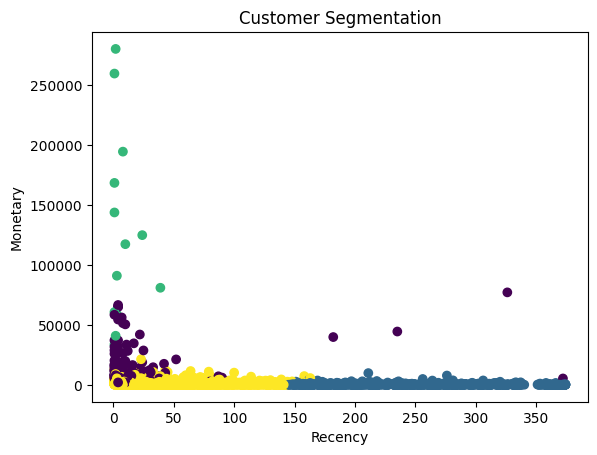

In [19]:
plt.scatter(rfm['Recency'], rfm['Monetary'], c=rfm['Cluster'])
plt.xlabel('Recency')
plt.ylabel('Monetary')
plt.title('Customer Segmentation')
plt.show()

In [20]:
rfm.groupby('Cluster')[['Recency','Frequency','Monetary']].mean()

,Recency,Frequency,Monetary
Cluster,,,
0,15.672986,22.047393,12453.225924
1,248.564030,1.551789,478.107581
2,7.384615,82.692308,127338.313846
3,43.910580,3.655748,1349.698298


In [21]:
rfm[['Cluster','Segment']].head()

,Cluster,Segment
CustomerID,,
12346.0,0,Loyal Customer
12347.0,3,Low Value Customer
12348.0,3,Low Value Customer
12349.0,3,Low Value Customer
12350.0,1,Lost Customer


In [22]:
rfm.groupby('Segment')[['Recency','Frequency','Monetary']].mean()

,Recency,Frequency,Monetary
Segment,,,
High Value Customer,7.384615,82.692308,127338.313846
Lost Customer,248.564030,1.551789,478.107581
Low Value Customer,43.910580,3.655748,1349.698298
Loyal Customer,15.672986,22.047393,12453.225924


In [23]:
import pickle
import os

os.makedirs("../model", exist_ok=True)

pickle.dump(kmeans, open("../model/kmeans.pkl", "wb"))
pickle.dump(scaler, open("../model/scaler.pkl", "wb"))
rfm.to_csv("../model/rfm.csv")
pickle.dump(wcss, open("../model/wcss.pkl", "wb"))